# Markov Model of Development Under Approval Uncertainty

A developer decides whether to apply for a building permit, knowing that:
- The business environment follows a **two-state Markov chain** (Good / Bad for building)
- Approval takes **T periods**, during which the state can change
- Applying costs **F** up front (filing fees, consultants, opportunity cost of staff time)
- The developer builds only if the environment is **Good** when approval arrives

The central question: **How does development respond to longer approval timelines T?**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'figure.dpi': 110,
})

## 1. Model Setup

### States and transition matrix

The market is either **Good** (G, state 0) or **Bad** (B, state 1). The 2×2 transition matrix is:

$$P = \begin{pmatrix} p & 1-p \\ q & 1-q \end{pmatrix}$$

where $p = P(G \to G)$ and $q = P(B \to G)$.

### Developer's problem

At time $t$, the developer observes state $s_t \in \{G, B\}$ and decides whether to apply. If they apply:
- Pay cost $F$ immediately
- Receive approval $T$ periods later
- At $t+T$, observe $s_{t+T}$: build if $s_{t+T} = G$ (earning $\pi$), do nothing if $s_{t+T} = B$

The expected payoff from applying in state $s$ with lag $T$ is:

$$V(s, T) = -F + \beta^T \cdot P^T_{sG} \cdot \pi$$

where $P^T_{sG} = \Pr(s_{t+T} = G \mid s_t = s)$ is the $T$-step transition probability and $\beta$ discounts future payoffs.

The developer applies iff $V(s, T) \geq 0$.

In [79]:
# ── Baseline parameters ────────────────────────────────────────────────────────
p     = 0.80   # P(Good -> Good): persistence of good market conditions
q     = 0.20   # P(Bad  -> Good): recovery rate out of bad conditions
F     = 0.50   # Fixed cost of applying (normalized so profit pi = 1)
pi    = 1.00   # Profit from building when state is Good at completion
beta  = 0.99   # Discount factor per period (reflects cost of capital)

# Transition matrix  (row = from, col = to;  state 0=Good, 1=Bad)
P_mat = np.array([[p,   1-p],
                  [q,   1-q]])

# ── Markov chain properties ────────────────────────────────────────────────────
pi_G = q / (1 - p + q)   # stationary P(Good)
pi_B = 1 - pi_G           # stationary P(Bad)
# Second eigenvalue of P. The diagonal entries are p and 1-q, so trace = p+(1-q),
# and eigenvalues sum to the trace: 1 + λ = p + (1-q)  →  λ = p - q.
lam  = p - q

print(f"Transition matrix P:")
print(f"  P(G→G) = {p:.2f},  P(G→B) = {1-p:.2f}")
print(f"  P(B→G) = {q:.2f},  P(B→B) = {1-q:.2f}")
print(f"\nStationary distribution:  π_G = {pi_G:.3f},  π_B = {pi_B:.3f}")
print(f"Mixing eigenvalue:         λ = p−q = {lam:.3f}")
print(f"Half-life of state memory: {np.log(0.5)/np.log(abs(lam)):.1f} periods")

Transition matrix P:
  P(G→G) = 0.80,  P(G→B) = 0.20
  P(B→G) = 0.20,  P(B→B) = 0.80

Stationary distribution:  π_G = 0.500,  π_B = 0.500
Mixing eigenvalue:         λ = p−q = 0.600
Half-life of state memory: 1.4 periods


## 2. T-Step Transition Probabilities

For a two-state chain the $T$-step probabilities have a closed form:

$$P^T_{GG} = \pi_G + (1 - \pi_G)\,\lambda^T$$
$$P^T_{BG} = \pi_G\,(1 - \lambda^T)$$

where $\lambda = p - q$ is the second eigenvalue of $P$ and $\pi_G = q/(1-p+q)$.

**Why $\lambda = p - q$?** The diagonal entries of $P$ are $p$ and $1-q$, so $\text{tr}(P) = p + (1-q)$. Since the eigenvalues of a stochastic matrix sum to the trace and one eigenvalue is always 1, the second eigenvalue satisfies $1 + \lambda = p + (1-q)$, giving $\lambda = p - q$.

Note: a common mistake is to write $\lambda = p + q - 1$, which would be correct if $q$ denoted $P(B \to B)$ (the *persistence* of the bad state). Here $q = P(B \to G)$ is the *recovery rate*, so $P(B\to B) = 1-q$ and the formula becomes $p + (1-q) - 1 = p - q$.

As $T \to \infty$, both $P^T_{GG}$ and $P^T_{BG}$ converge to $\pi_G$. The speed of convergence is governed by $|\lambda| = |p - q|$.

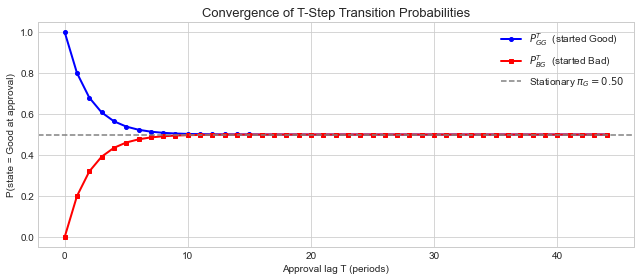

Key: for large T, both states face the same approval-time odds.
     That shared probability is π_G = 0.500


In [80]:
def prob_good_at_T(s, T, p, q):
    """P(state = Good at t+T | state = s at t).  s: 0=Good, 1=Bad."""
    pi_G_ = q / (1 - p + q)
    lam_  = p - q              # second eigenvalue: trace - 1 = p + (1-q) - 1 = p - q
    if s == 0:
        return pi_G_ + (1 - pi_G_) * lam_**T
    else:
        return pi_G_ * (1 - lam_**T)

# Sanity check: at T=1 should recover P exactly
assert abs(prob_good_at_T(0, 1, p, q) - p) < 1e-12, "P^1_GG != p"
assert abs(prob_good_at_T(1, 1, p, q) - q) < 1e-12, "P^1_BG != q"

T_vals = np.arange(0, 45)
p_GG = np.array([prob_good_at_T(0, T, p, q) for T in T_vals])
p_BG = np.array([prob_good_at_T(1, T, p, q) for T in T_vals])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(T_vals, p_GG, 'b-o', ms=4, lw=2, label=r'$P^T_{GG}$  (started Good)')
ax.plot(T_vals, p_BG, 'r-s', ms=4, lw=2, label=r'$P^T_{BG}$  (started Bad)')
ax.axhline(pi_G, color='gray', ls='--', lw=1.5, label=f'Stationary $\\pi_G = {pi_G:.2f}$')
ax.set_xlabel('Approval lag T (periods)')
ax.set_ylabel('P(state = Good at approval)')
ax.set_title('Convergence of T-Step Transition Probabilities')
ax.legend()
plt.tight_layout()
plt.show()

print("Key: for large T, both states face the same approval-time odds.")
print(f"     That shared probability is π_G = {pi_G:.3f}")

## 3. Developer's Value Function and Decision Rule

The value of applying:
$$V(s, T) = -F + \beta^T \cdot P^T_{sG} \cdot \pi$$

Two forces reduce $V$ as $T$ grows:
1. **State uncertainty**: $P^T_{GG}$ falls toward $\pi_G < 1$, so a Good-state developer becomes less sure the market will still be good at approval
2. **Discounting**: $\beta^T$ shrinks — future profits are worth less

For Bad-state developers, $P^T_{BG}$ rises toward $\pi_G$ as T increases (more time to recover), but discounting still erodes value.

There is a **critical lag** $T^*_s$ beyond which developers in state $s$ stop applying.

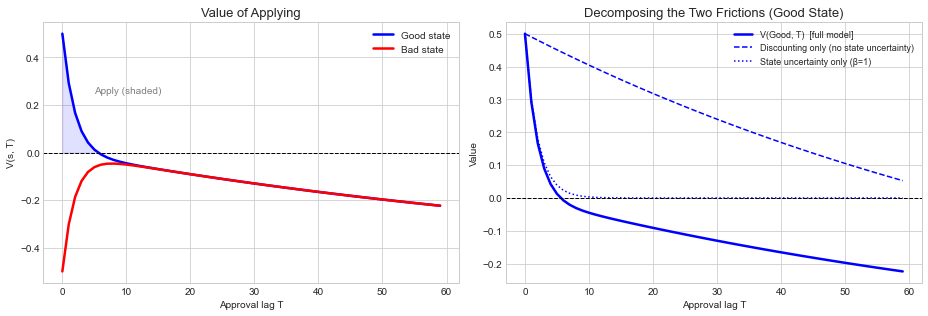

T*(Good) = 6  (developer stops applying beyond this lag)
T*(Bad ) = 0  (developer stops applying beyond this lag)


In [81]:
def V(s, T, p, q, F=F, pi=pi, beta=beta):
    return -F + beta**T * prob_good_at_T(s, T, p, q) * pi

T_vals = np.arange(0, 60)
V_G = np.array([V(0, T, p, q) for T in T_vals])
V_B = np.array([V(1, T, p, q) for T in T_vals])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── Left: value function ───────────────────────────────────────────────────────
ax = axes[0]
ax.plot(T_vals, V_G, 'b-', lw=2.5, label='Good state')
ax.plot(T_vals, V_B, 'r-', lw=2.5, label='Bad state')
ax.axhline(0, color='k', ls='--', lw=1)
ax.fill_between(T_vals, V_G, 0, where=(V_G >= 0), alpha=0.12, color='blue')
ax.fill_between(T_vals, V_B, 0, where=(V_B >= 0), alpha=0.12, color='red')
ax.set_xlabel('Approval lag T')
ax.set_ylabel('V(s, T)')
ax.set_title('Value of Applying')
ax.legend()
ax.annotate('Apply (shaded)', xy=(5, 0.25), fontsize=10, color='gray')

# ── Right: decision thresholds ─────────────────────────────────────────────────
ax = axes[1]
# Decompose: discount factor vs state-uncertainty components
discount_only = np.array([beta**T * pi - F for T in T_vals])          # if always Good
uncertainty_G = np.array([prob_good_at_T(0, T, p, q) * pi - F for T in T_vals])  # no discounting
ax.plot(T_vals, V_G,          'b-',  lw=2.5, label='V(Good, T)  [full model]')
ax.plot(T_vals, discount_only,'b--', lw=1.5, label='Discounting only (no state uncertainty)')
ax.plot(T_vals, uncertainty_G,'b:',  lw=1.5, label='State uncertainty only (β=1)')
ax.axhline(0, color='k', ls='--', lw=1)
ax.set_xlabel('Approval lag T')
ax.set_ylabel('Value')
ax.set_title('Decomposing the Two Frictions (Good State)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Print critical lags
for s, name, Vvec in [(0, 'Good', V_G), (1, 'Bad', V_B)]:
    below = np.where(Vvec < 0)[0]
    T_star = T_vals[below[0]] if len(below) > 0 else '>60'
    print(f"T*({name:4s}) = {T_star}  (developer stops applying beyond this lag)")

## 4. Analytical Development Rate vs. T

In steady state (weighting by the stationary distribution):

$$\text{Application rate}(T) = \pi_G \cdot \mathbf{1}[V(G,T) \geq 0] + \pi_B \cdot \mathbf{1}[V(B,T) \geq 0]$$

$$\text{Building rate}(T) = \pi_G \cdot \mathbf{1}[V(G,T) \geq 0] \cdot P^T_{GG} + \pi_B \cdot \mathbf{1}[V(B,T) \geq 0] \cdot P^T_{BG}$$

The building rate measures completed buildings per period in steady state.

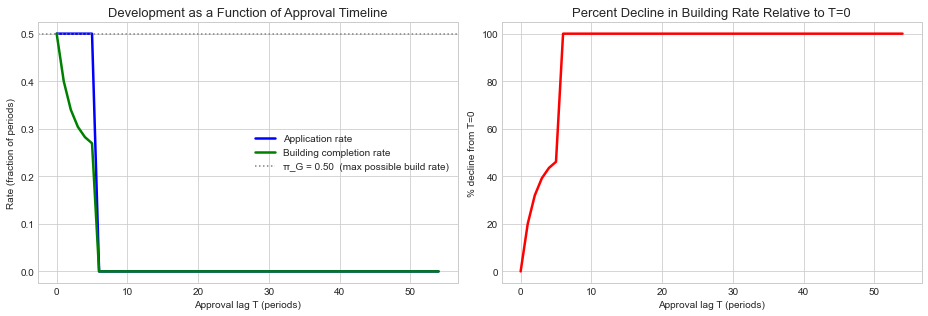

Building rate at T=0:   0.500
Building rate at T=10:  0.000  (100.0% decline)
Building rate at T=20:  0.000  (100.0% decline)


In [82]:
def development_rates(T_range, p=p, q=q, F=F, pi=pi, beta=beta):
    pi_G_ = q / (1 - p + q)
    pi_B_ = 1 - pi_G_
    app_rates, build_rates = [], []

    for T in T_range:
        vG = V(0, T, p, q, F, pi, beta)
        vB = V(1, T, p, q, F, pi, beta)
        aG = float(vG >= 0)
        aB = float(vB >= 0)
        pGG = prob_good_at_T(0, T, p, q)
        pBG = prob_good_at_T(1, T, p, q)

        app_rates.append(pi_G_ * aG + pi_B_ * aB)
        build_rates.append(pi_G_ * aG * pGG + pi_B_ * aB * pBG)

    return np.array(app_rates), np.array(build_rates)

T_range = np.arange(0, 55)
app_r, build_r = development_rates(T_range)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(T_range, app_r,   'b-', lw=2.5, label='Application rate')
ax.plot(T_range, build_r, 'g-', lw=2.5, label='Building completion rate')
ax.axhline(pi_G, color='gray', ls=':', label=f'π_G = {pi_G:.2f}  (max possible build rate)')
ax.set_xlabel('Approval lag T (periods)')
ax.set_ylabel('Rate (fraction of periods)')
ax.set_title('Development as a Function of Approval Timeline')
ax.legend()

# ── Percentage decline from T=0 ────────────────────────────────────────────────
ax = axes[1]
pct_decline = 100 * (build_r[0] - build_r) / max(build_r[0], 1e-9)
ax.plot(T_range, pct_decline, 'r-', lw=2.5)
ax.set_xlabel('Approval lag T (periods)')
ax.set_ylabel('% decline from T=0')
ax.set_title('Percent Decline in Building Rate Relative to T=0')

plt.tight_layout()
plt.show()

print(f"Building rate at T=0:   {build_r[0]:.3f}")
print(f"Building rate at T=10:  {build_r[10]:.3f}  ({100*(build_r[0]-build_r[10])/build_r[0]:.1f}% decline)")
print(f"Building rate at T=20:  {build_r[20]:.3f}  ({100*(build_r[0]-build_r[20])/build_r[0]:.1f}% decline)")

## 5. Simulation

We now simulate the Markov chain and apply the decision rule period-by-period. This lets us:
- **Validate** the analytical results
- **Track** the time series of applications and completions
- **Visualize** how the pipeline of pending applications builds up

In [83]:
def simulate(T, p=p, q=q, F=F, pi=pi, beta=beta, N=8000, seed=42):
    """
    Simulate N periods of the Markov chain and record application/build decisions.

    Returns a dict with summary statistics and time-series arrays.
    """
    rng = np.random.default_rng(seed)
    pi_G_ = q / (1 - p + q)
    P_loc = np.array([[p, 1-p], [q, 1-q]])

    # Draw states for N + T periods (extra T needed for look-ahead at t+T)
    states = np.empty(N + T, dtype=int)
    states[0] = 0 if rng.random() < pi_G_ else 1   # draw from stationary
    for t in range(1, N + T):
        states[t] = rng.choice(2, p=P_loc[states[t-1]])

    applies = np.zeros(N, dtype=bool)
    builds  = np.zeros(N, dtype=bool)

    for t in range(N):
        s = states[t]
        if V(s, T, p, q, F, pi, beta) >= 0:
            applies[t] = True
            builds[t]  = (states[t + T] == 0)   # build iff Good at completion

    return {
        'T': T,
        'states': states[:N],
        'applies': applies,
        'builds': builds,
        'app_rate': applies.mean(),
        'build_rate': builds.mean(),
        'cond_build': builds.sum() / max(applies.sum(), 1),
    }

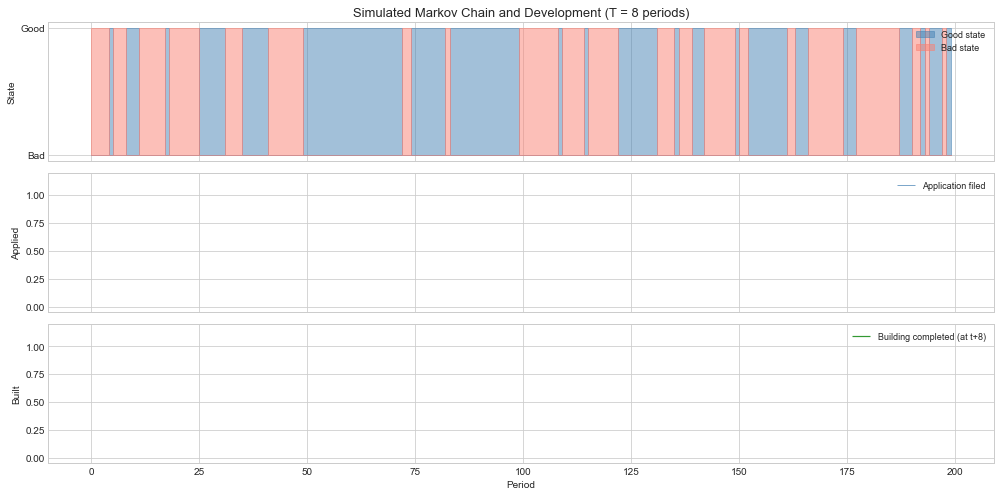

In [84]:
# ── Run simulation for a single T and visualize the time series ────────────────
T_example = 8
sim = simulate(T_example)

# Show first 200 periods
window = 200
t_axis = np.arange(window)
states_w  = sim['states'][:window]
applies_w = sim['applies'][:window]
builds_w  = sim['builds'][:window]

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

ax = axes[0]
ax.fill_between(t_axis, 0, 1 - states_w, step='post',
                color='steelblue', alpha=0.5, label='Good state')
ax.fill_between(t_axis, 0, states_w, step='post',
                color='salmon', alpha=0.5, label='Bad state')
ax.set_ylabel('State')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Bad', 'Good'])
ax.set_title(f'Simulated Markov Chain and Development (T = {T_example} periods)')
ax.legend(loc='upper right', fontsize=9)

ax = axes[1]
ax.vlines(t_axis[applies_w], 0, 1, color='steelblue', alpha=0.7, lw=1, label='Application filed')
ax.set_ylabel('Applied')
ax.set_ylim(-0.05, 1.2)
ax.legend(loc='upper right', fontsize=9)

ax = axes[2]
ax.vlines(t_axis[builds_w], 0, 1, color='green', alpha=0.8, lw=1.2, label=f'Building completed (at t+{T_example})')
ax.set_ylabel('Built')
ax.set_ylim(-0.05, 1.2)
ax.set_xlabel('Period')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

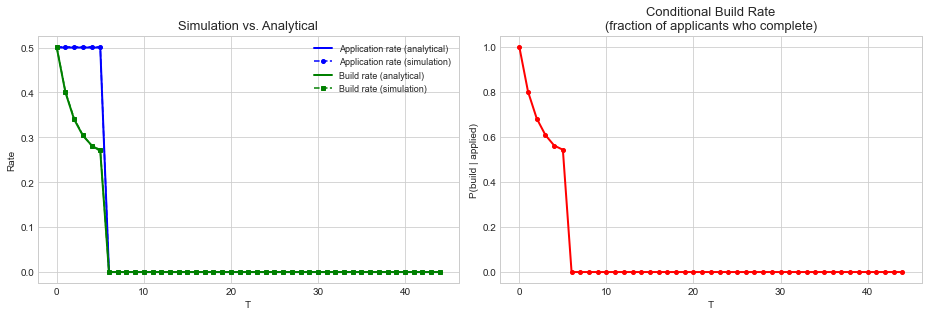

In [85]:
# ── Validate simulation against analytical results ─────────────────────────────
T_sim_range = np.arange(0, 45)
sim_results = [simulate(T) for T in T_sim_range]
df_sim = pd.DataFrame([
    {'T': r['T'], 'app_rate': r['app_rate'], 'build_rate': r['build_rate'],
     'cond_build': r['cond_build']}
    for r in sim_results
])

app_a, build_a = development_rates(T_sim_range)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(T_sim_range, app_a,              'b-',   lw=2,   label='Application rate (analytical)')
ax.plot(df_sim['T'], df_sim['app_rate'], 'b--o', ms=4,   label='Application rate (simulation)')
ax.plot(T_sim_range, build_a,              'g-',  lw=2,   label='Build rate (analytical)')
ax.plot(df_sim['T'], df_sim['build_rate'], 'g--s', ms=4,  label='Build rate (simulation)')
ax.set_xlabel('T')
ax.set_ylabel('Rate')
ax.set_title('Simulation vs. Analytical')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(df_sim['T'], df_sim['cond_build'], 'r-o', ms=4, lw=2)
ax.set_xlabel('T')
ax.set_ylabel('P(build | applied)')
ax.set_title('Conditional Build Rate\n(fraction of applicants who complete)')

plt.tight_layout()
plt.show()

## 6. Comparative Statics

How does the development-vs-T curve shift with the underlying parameters?

| Parameter | Economic meaning | Expected effect on build rate |
|-----------|-----------------|-------------------------------|
| $\beta$  | Cost of capital (lower β = higher cost) | Lower β → sharper decline with T |
| $p$      | Persistence of good conditions | Higher p → slower decline (Good state stays good longer) |
| $q$      | Recovery rate from bad conditions | Higher q → higher baseline rate; Bad-state developers may apply at intermediate T |
| $F$      | Application cost | Higher F → shorter window where applications are profitable |

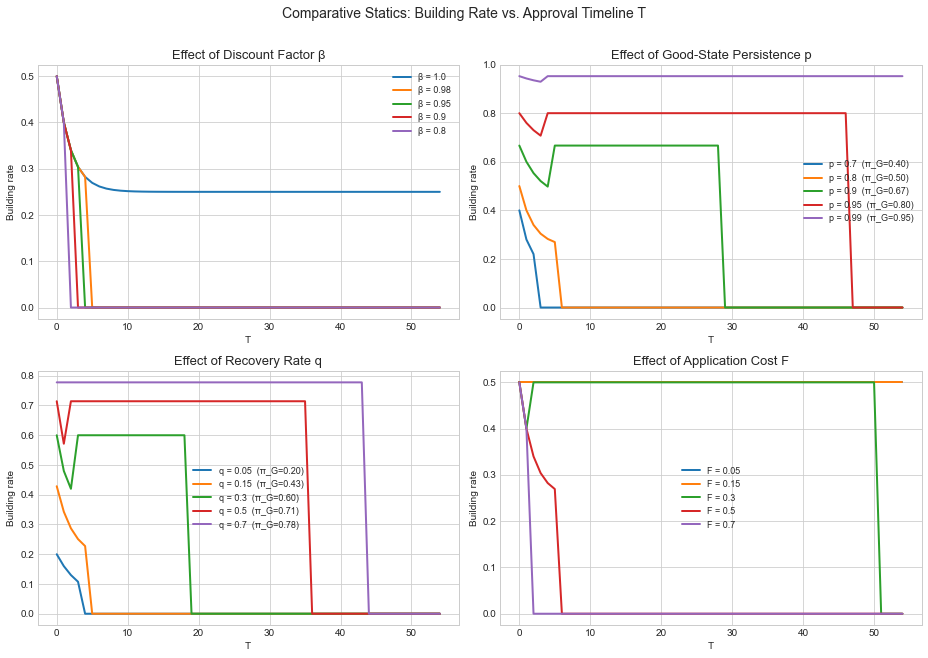

In [86]:
T_cs = np.arange(0, 55)
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ── β: discount factor ─────────────────────────────────────────────────────────
ax = axes[0, 0]
for beta_val in [1.00, 0.98, 0.95, 0.90, 0.80]:
    _, br = development_rates(T_cs, p=p, q=q, F=F, pi=pi, beta=beta_val)
    ax.plot(T_cs, br, lw=2, label=f'β = {beta_val}')
ax.set_xlabel('T');  ax.set_ylabel('Building rate')
ax.set_title('Effect of Discount Factor β')
ax.legend(fontsize=9)

# ── p: good-state persistence ──────────────────────────────────────────────────
ax = axes[0, 1]
for p_val in [0.70, 0.80, 0.90, 0.95, 0.99]:
    _, br = development_rates(T_cs, p=p_val, q=q, F=F, pi=pi, beta=beta)
    pi_G_v = q / (1 - p_val + q)
    ax.plot(T_cs, br, lw=2, label=f'p = {p_val}  (π_G={pi_G_v:.2f})')
ax.set_xlabel('T');  ax.set_ylabel('Building rate')
ax.set_title('Effect of Good-State Persistence p')
ax.legend(fontsize=9)

# ── q: recovery rate ───────────────────────────────────────────────────────────
ax = axes[1, 0]
for q_val in [0.05, 0.15, 0.30, 0.50, 0.70]:
    _, br = development_rates(T_cs, p=p, q=q_val, F=F, pi=pi, beta=beta)
    pi_G_v = q_val / (1 - p + q_val)
    ax.plot(T_cs, br, lw=2, label=f'q = {q_val}  (π_G={pi_G_v:.2f})')
ax.set_xlabel('T');  ax.set_ylabel('Building rate')
ax.set_title('Effect of Recovery Rate q')
ax.legend(fontsize=9)

# ── F: application cost ────────────────────────────────────────────────────────
ax = axes[1, 1]
for F_val in [0.05, 0.15, 0.30, 0.50, 0.70]:
    _, br = development_rates(T_cs, p=p, q=q, F=F_val, pi=pi, beta=beta)
    ax.plot(T_cs, br, lw=2, label=f'F = {F_val}')
ax.set_xlabel('T');  ax.set_ylabel('Building rate')
ax.set_title('Effect of Application Cost F')
ax.legend(fontsize=9)

plt.suptitle('Comparative Statics: Building Rate vs. Approval Timeline T', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Extension: Heterogeneous Developers

With a single $F$, the application decision is binary (apply or not). A more realistic model has developers with heterogeneous costs $F_j \sim \text{Uniform}[0, \pi]$. Then the fraction who apply is a smooth function of T:

$$\text{Pr(apply} \mid s) = \Pr\!\left(F_j \leq \beta^T P^T_{sG}\, \pi\right) = \beta^T P^T_{sG}$$

This gives a smooth, differentiable development rate that is easier to estimate empirically.

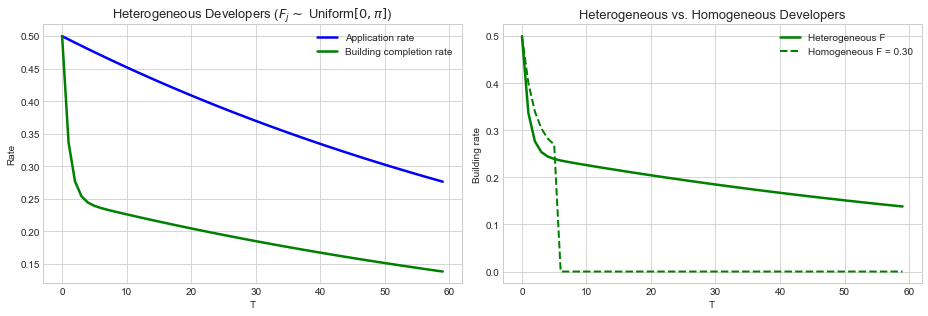

In [87]:
def development_rates_heterogeneous(T_range, p=p, q=q, pi=pi, beta=beta):
    """F_j ~ Uniform[0, pi].  Application prob = fraction with F_j <= beta^T * P^T_sG * pi."""
    pi_G_ = q / (1 - p + q)
    pi_B_ = 1 - pi_G_
    app_r, build_r = [], []

    for T in T_range:
        disc = beta**T
        pGG  = prob_good_at_T(0, T, p, q)
        pBG  = prob_good_at_T(1, T, p, q)

        # Fraction who apply = CDF of Uniform[0,pi] at threshold
        apply_G = np.clip(disc * pGG, 0, 1)
        apply_B = np.clip(disc * pBG, 0, 1)

        app_r.append(pi_G_ * apply_G + pi_B_ * apply_B)
        build_r.append(pi_G_ * apply_G * pGG + pi_B_ * apply_B * pBG)

    return np.array(app_r), np.array(build_r)

T_het = np.arange(0, 60)
app_het, build_het = development_rates_heterogeneous(T_het)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(T_het, app_het,   'b-', lw=2.5, label='Application rate')
ax.plot(T_het, build_het, 'g-', lw=2.5, label='Building completion rate')
ax.set_xlabel('T');  ax.set_ylabel('Rate')
ax.set_title('Heterogeneous Developers ($F_j \\sim$ Uniform$[0,\\pi]$)')
ax.legend()

# Compare to homogeneous
ax = axes[1]
_, build_hom = development_rates(T_het)
ax.plot(T_het, build_het, 'g-',  lw=2.5, label='Heterogeneous F')
ax.plot(T_het, build_hom, 'g--', lw=2,   label='Homogeneous F = 0.30')
ax.set_xlabel('T');  ax.set_ylabel('Building rate')
ax.set_title('Heterogeneous vs. Homogeneous Developers')
ax.legend()

plt.tight_layout()
plt.show()

## 8. The Aggregate Effect of Longer Timelines

We can compute the **elasticity of development with respect to the approval lag** at each T.

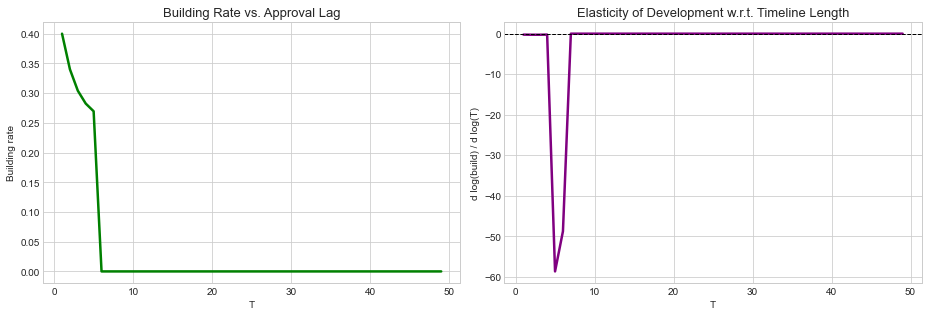

Elasticity at T=5:   -58.69
Elasticity at T=10:  0.0
Elasticity at T=20:  0.0


In [88]:
T_elas = np.arange(1, 50)
_, build_elas = development_rates(T_elas)

# Numerical elasticity: d log(build_rate) / d log(T)
elasticity = np.gradient(np.log(np.maximum(build_elas, 1e-9)), np.log(T_elas))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(T_elas, build_elas, 'g-', lw=2.5)
ax.set_xlabel('T');  ax.set_ylabel('Building rate')
ax.set_title('Building Rate vs. Approval Lag')

ax = axes[1]
ax.plot(T_elas, elasticity, 'purple', lw=2.5)
ax.axhline(0, color='k', ls='--', lw=1)
ax.set_xlabel('T');  ax.set_ylabel('d log(build) / d log(T)')
ax.set_title('Elasticity of Development w.r.t. Timeline Length')

plt.tight_layout()
plt.show()

print("Elasticity at T=5:  ", round(elasticity[4], 3))
print("Elasticity at T=10: ", round(elasticity[9], 3))
print("Elasticity at T=20: ", round(elasticity[19], 3))

In [89]:
# ── Policy experiment: reduce T by 5 periods ───────────────────────────────────
T_baseline = 15
T_reform   = T_baseline - 5

_, br_baseline = development_rates([T_baseline])
_, br_reform   = development_rates([T_reform])

pct_gain = 100 * (br_reform[0] - br_baseline[0]) / max(br_baseline[0], 1e-9)

print("Policy experiment: reduce approval lag from", T_baseline, "to", T_reform, "periods")
print(f"  Building rate (baseline):  {br_baseline[0]:.4f}")
print(f"  Building rate (reform):    {br_reform[0]:.4f}")
print(f"  Gain:                     +{pct_gain:.1f}%")

Policy experiment: reduce approval lag from 15 to 10 periods
  Building rate (baseline):  0.0000
  Building rate (reform):    0.0000
  Gain:                     +0.0%


## Key Takeaways

1. **Development falls with T, but not linearly.** Two separate forces operate:
   - *State uncertainty*: the longer the lag, the less the current state predicts the state at approval
   - *Discounting*: future profits are worth less at rate $\beta^T$

2. **The Good-state developer is most sensitive to T.** They start with a high probability of a good outcome ($P^0_{GG} = 1$), but this erodes toward $\pi_G < 1$ as T grows. Bad-state developers have little to lose.

3. **There is a critical lag $T^*$** beyond which applications stop entirely. For a Good-state developer, $T^*$ solves $\beta^{T^*} P^{T^*}_{GG} \pi = F$.

4. **High persistence $p$ buffers against long lags.** If the Good state is very persistent, $P^T_{GG}$ stays high for a long time, so developers remain willing to apply even with long timelines.

5. **Higher F compresses the feasible range of T.** The threshold condition is easier to violate when the fixed cost is large, so costly permit applications are more sensitive to timeline length.

6. **Empirical implication.** In a regression of build probability on project profitability $\pi_j$, entitlement barrier $O_j$, and timeline $T_j$, the model predicts a negative interaction $T_j \times \pi_j$ — longer timelines erode the advantage of higher-profit projects.